# EmporiUm Sales Territory Analysis
**Analyst:** Sharleen Guerrero  
**Territories:** Texas (South Region) & New Jersey (Northeast Region) — `*Cross-Region Comparison*`  
**Territory Managers:** Jeff "Howdy" Richards (TX) | Miami Vue (NJ)  
**Project Objective:** 
>The objective of this project is to conduct a comprehensive business analysis of five datasets covering store details and product performance across regions for a fictional bookstore chain called EmporiUm. The analysis focuses on comparing the South and Northeast regions, specifically the Texas and New Jersey sales territories. Key insights will be explored using Python libraries *NumPy*, *Pandas*, and *Matplotlib* to identify performance trends, and data-driven recommendations will be provided for where to focus marketing attention in the next quarter. All analysis and findings are documented in this Jupyter Notebook. Visualizations are located throughout analysis.



---

## 1. Loading and Inspecting Data with Pandas

In [1]:
# ====== Importing necessary libraries ======

# pandas — data manipulation and DataFrames 
import pandas as pd

# numpy — numerical computing, used for array operations 
import numpy as np

# matplotlib — creating static charts and visualizations 
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker # formatting axis tick labels (ex. currency symbols)

In [2]:
# ====== Creating DataFrames ======

# pd.read_csv() - A Pandas library function that converts csv files into DataFrames
# df.info() Gives column names, data types, and non-null values
# df.head() shows first 5 rows 
# df.shape returns a tuple with DataFrame dimensions (rows, columns)

# ------ customer_list.csv ------ # 

# raw customer_list.csv uses pipe symbols | as delimiters
# split by '|' to properly display columns
customer_list = pd.read_csv("customer_list.csv", sep='|')

# DataFrame Inspection Methods & Attributes
print("\n----------- customer_list info: -----------\n")
customer_list.info()
print("\ncustomer_list Shape:", customer_list.shape)
print("\n------------ Initial Rows: ----------------\n")
customer_list.head()


----------- customer_list info: -----------

<class 'pandas.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   cust_id       521 non-null    int64
 1   date          521 non-null    str  
 2   time          521 non-null    str  
 3   name          521 non-null    str  
 4   email         521 non-null    str  
 5   phone         520 non-null    str  
 6   sms-opt-out   520 non-null    str  
dtypes: int64(1), str(6)
memory usage: 28.6 KB

customer_list Shape: (521, 7)

------------ Initial Rows: ----------------



,cust_id,date,time,name,email,phone,sms-opt-out
0,1,2023-03-15,08:45:12,Rachel,rachel@centralperk.coffee,212-555-1001,N
1,2,2023-05-22,12:30:45,R. Geller,rossg@centralperk.coffee,212-555-1002,N
2,3,2023-07-09,18:15:27,Monica Geller,chefmonica@centralperk.coffee,212-555-1003,N
3,4,2023-09-01,21:05:33,Chandler Bing,chandlerb@centralperk.coffee,212-555-1004,Y
4,5,2023-11-18,14:22:10,Joey,howyoudoing@centralperk.coffee,212-555-1005,N


In [3]:
# ------ ProductCategories.csv ------ # 

product_categories = pd.read_csv("ProductCategories.csv")

print("\n----------- product_categories info: -----------\n")
product_categories.info()
print("\nproduct_categories Shape:", product_categories.shape)
print("\n--------------- Initial Rows: ------------------\n")
product_categories.head()


----------- product_categories info: -----------

<class 'pandas.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   CategoryID     52 non-null     int64
 1   Category       52 non-null     str  
 2   SubcategoryID  52 non-null     str  
 3   Subcategory    52 non-null     str  
dtypes: int64(1), str(3)
memory usage: 1.8 KB

product_categories Shape: (52, 4)

--------------- Initial Rows: ------------------



,CategoryID,Category,SubcategoryID,Subcategory
0,120,Technology & Accessories,120-tab,Tablets
1,120,Technology & Accessories,120-cal,Calculators
2,120,Technology & Accessories,120-sof,Software Download
3,120,Technology & Accessories,120-hea,Headphones
4,120,Technology & Accessories,120-ext,External Accessories


In [4]:
# ------ Products.csv ------ # 
products = pd.read_csv("Products.csv")

print("\n------------ products info: ------------\n")
products.info()
print("\nproducts Shape:", products.shape)
print("\n-------------Initial Rows: -------------\n")
products.head()


------------ products info: ------------

<class 'pandas.DataFrame'>
RangeIndex: 669 entries, 0 to 668
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Prod Num       669 non-null    str  
 1   Product        669 non-null    str  
 2   CategoryID     669 non-null    int64
 3   SubcategoryID  669 non-null    str  
dtypes: int64(1), str(3)
memory usage: 21.0 KB

products Shape: (669, 4)

-------------Initial Rows: -------------



,Prod Num,Product,CategoryID,SubcategoryID
0,105248-IT,TCL NXTPAPER 10s,120,120-tab
1,105249-IT,Dell Latitude 7320 Detachable,120,120-tab
2,105250-IT,Realme Pad,120,120-tab
3,105251-IT,Lenovo Tab P12 Pro,120,120-tab
4,105252-IT,Microsoft Surface Pro 9,120,120-tab


In [5]:
# ------ StoreDetails.csv ------ #  
store_details = pd.read_csv("StoreDetail.csv")

print("\n----------- store_details info: ----------\n")
store_details.info()
print("\nstore_details Shape:", store_details.shape)
print("\n------------ Initial Rows: ----------------\n")
store_details.head()


----------- store_details info: ----------

<class 'pandas.DataFrame'>
RangeIndex: 111 entries, 0 to 110
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Store Location     111 non-null    str  
 1   State              111 non-null    str  
 2   Store ID           111 non-null    int64
 3   Territory Manager  111 non-null    str  
 4   Region             111 non-null    str  
 5   Region Director    111 non-null    str  
dtypes: int64(1), str(5)
memory usage: 5.3 KB

store_details Shape: (111, 6)

------------ Initial Rows: ----------------



,Store Location,State,Store ID,Territory Manager,Region,Region Director
0,Aurora,Colorado,701,Jim Heck,West,Cassie Chambers
1,Berthoud,Colorado,702,Jim Heck,West,Cassie Chambers
2,Boulder,Colorado,703,Jim Heck,West,Cassie Chambers
3,Castle Rock,Colorado,704,Jim Heck,West,Cassie Chambers
4,Denver,Colorado,705,Jim Heck,West,Cassie Chambers


In [6]:
# ------ StoreSales.csv ------ # 
store_sales = pd.read_csv("StoreSales.csv")

print("\n----------- store_sales info: ----------\n")
store_sales.info()
print("\nstore_sales Shape:", store_sales.shape)
print("\n------------ Initial Rows: ----------------\n")
store_sales.head()


----------- store_sales info: ----------

<class 'pandas.DataFrame'>
RangeIndex: 335129 entries, 0 to 335128
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Transaction Date  335129 non-null  str    
 1   Store ID          335129 non-null  int64  
 2   RewardsID         34943 non-null   float64
 3   Prod Num          335129 non-null  str    
 4   Sale Amount       335129 non-null  float64
dtypes: float64(2), int64(1), str(2)
memory usage: 12.8 MB

store_sales Shape: (335129, 5)

------------ Initial Rows: ----------------



,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount
0,1/1/2022,702,NaN,105349-M,8.00
1,1/1/2022,704,NaN,105350-T,144.00
2,1/1/2022,705,NaN,105351-M,44.00
3,1/1/2022,705,NaN,105352-M,47.61
4,1/1/2022,705,NaN,105353-A,20.36


### 1.A Initial Data Inspection Observations

- Transaction Date in StoreSales (and possibly customer_list) must be converted to datetime using pd.to_datetime() before analysis to perform date operations
- RewardsID is float because NaN values exist, indicating non-rewards customers. Pandas automatically converts int columns with NaN to float
- Prod Num and SubcategoryID are intentionally strings because they include letters. Primary use is labels and join keys, not calculation.
- Null values were found in RewardsID (300,186 nulls) indicating 
  non-rewards customers, and minor nulls in customer_list phone 
  and sms-opt-out columns (1 null each). This doesn't impede overall analysis.

### 1.B Data Cleaning

In [7]:
# Priority is converting Transaction Date column in store_sales from a default string to 
# date for chronological awareness using pd.to_datetime method
store_sales['Transaction Date'] = pd.to_datetime(store_sales['Transaction Date'])

# Creating a YearMonth column for seamless grouping by transaction months for analysis
store_sales['YearMonth'] = store_sales['Transaction Date'].dt.to_period('M')

# Verifying Both Changes
store_sales[['Transaction Date', 'YearMonth']].head()

,Transaction Date,YearMonth
0,2022-01-01,2022-01
1,2022-01-01,2022-01
2,2022-01-01,2022-01
3,2022-01-01,2022-01
4,2022-01-01,2022-01


In [8]:
# What is the full date range of the data?
print(store_sales['YearMonth'].min())
print(store_sales['YearMonth'].max())

2022-01
2025-12


In [9]:
# Final Check
# Checking for duplicate rows
print("Duplicate rows found: ", store_sales.duplicated().sum())

# Check for anomalies: negative or zero sale amounts 
check1 = (store_sales[store_sales['Sale Amount'] <= 0].shape)
print("\nSale amounts less than or equal to 0 (anomalies): ", check1[0])

# Check Transaction Date format consistency
print("\nTransaction Date Format Check:")
check2 = store_sales['Transaction Date'].head(10)
check2

Duplicate rows found:  0

Sale amounts less than or equal to 0 (anomalies):  0

Transaction Date Format Check:


0   2022-01-01
1   2022-01-01
2   2022-01-01
3   2022-01-01
4   2022-01-01
5   2022-01-01
6   2022-01-01
7   2022-01-01
8   2022-01-01
9   2022-01-01
Name: Transaction Date, dtype: datetime64[us]

>**Data covers 48 months of transactions from January 2022 through December 2025.**


>**Data is clean and ready for analysis!**

---

## 2. Core Marketing Analysis

This analysis examines sales performance across the Texas and New Jersey territories, covering revenue trends, store rankings, customer behavior, product category performance, and marketing recommendations for the next quarter.


### Q1 | Territory Overview
*Who are the territory managers for the sales territories assigned?*

In [10]:
# Using .isin() function to filter information by assigned territories and store the result 
# in an assigned territory table for automatically filtered analysis
assigned_territories = store_details[store_details['State'].isin(['Texas', 'New Jersey'])]

# Finding territory manager names for each assigned state and storing them in respective variables
# .unique() returns an array of distinct values; [0] extracts the first item as a string
texas_manager = assigned_territories[assigned_territories['State'] == 'Texas']['Territory Manager'].unique()[0]
nj_manager = assigned_territories[assigned_territories['State'] == 'New Jersey']['Territory Manager'].unique()[0]

# Printing the results
print(f"Territory Manager for Texas: {texas_manager}")
print(f"Territory Manager for New Jersey: {nj_manager}")

Territory Manager for Texas: Jeff "Howdy" Richards
Territory Manager for New Jersey: Miami Vue


&nbsp;

*What are the store IDs and cities for the stores in each assigned sales territory?*

In [11]:
# Filtering only relevant columns for Texas territory stores
texas_stores = assigned_territories[assigned_territories['State'] == 'Texas'][['Store Location', 'Store ID', 'Region']]
print(f"\nTexas has {len(texas_stores)} stores")
texas_stores


Texas has 11 stores


,Store Location,Store ID,Region
100,Arlington,901,South
101,Austin,902,South
102,Bacliff,903,South
103,Baytown,904,South
104,Beaumont,905,South
105,Cedar Park,906,South
106,Dallas,907,South
107,Denton,908,South
108,Desoto,909,South
109,Fort Worth,910,South


In [12]:
# Filtering only relevant columns for New Jersey territory stores
nj_stores = assigned_territories[assigned_territories['State'] == 'New Jersey'][['Store Location', 'Store ID', 'Region']]
print(f"\nNew Jersey has {len(nj_stores)} stores")
nj_stores


New Jersey has 16 stores


,Store Location,Store ID,Region
70,Atlantic City,824,Northeast
71,Bayonne,825,Northeast
72,Cape May,826,Northeast
73,Clifton,827,Northeast
74,East Orange,828,Northeast
75,Hackensack,829,Northeast
76,Hoboken,830,Northeast
77,Jersey City,831,Northeast
78,Montclair,832,Northeast
79,Morristown,833,Northeast


**Q1 Findings — Territory Overview**

- The Texas territory, managed by Jeff "Howdy" Richards, consists of **11 stores** (Store IDs 901-911).
- The New Jersey territory, managed by Miami Vue, consists of **16 stores** (Store IDs 824-839).

Notably, New Jersey in the Northeast region has five more stores than Texas in the South Region. Despite having 5 fewer stores, Texas will be evaluated on revenue-per-store efficiency to determine whether store count or sales strategy drives performance differences.

### Q2 | Monthly Territory Revenue Performance
*What is the monthly total revenue for in-store sales in Texas and New Jersey individually, over the full period covered by the data?*

In [13]:
# Merging store_sales and filtered assigned territory tables through shared Store ID
territory_sales = pd.merge(store_sales, assigned_territories, on='Store ID', how='inner')

# Displaying merged data with stores sales specifially for Texas and New Jersey territories
territory_sales.head()

,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount,YearMonth,Store Location,State,Territory Manager,Region,Region Director
0,2022-01-01,824,NaN,105337-IT,1301.88,2022-01,Atlantic City,New Jersey,Miami Vue,Northeast,Michael Jarvis
1,2022-01-01,826,513.0,105435-A,18.00,2022-01,Cape May,New Jersey,Miami Vue,Northeast,Michael Jarvis
2,2022-01-01,826,NaN,105436-S,4.32,2022-01,Cape May,New Jersey,Miami Vue,Northeast,Michael Jarvis
3,2022-01-01,827,122.0,105274-IT,296.60,2022-01,Clifton,New Jersey,Miami Vue,Northeast,Michael Jarvis
4,2022-01-01,828,NaN,105437-T,187.25,2022-01,East Orange,New Jersey,Miami Vue,Northeast,Michael Jarvis


In [14]:
# Finding monthly revenue for each state through filtered territory sales using .groupby
# Resetting index at the end turn the groupby keys into regular columns and therefore referenceable in charts
monthly_revenue = territory_sales.groupby(['State', 'YearMonth'])['Sale Amount'].sum().reset_index()
monthly_revenue

,State,YearMonth,Sale Amount
0,New Jersey,2022-01,70597.51
1,New Jersey,2022-02,63225.69
2,New Jersey,2022-03,64779.71
3,New Jersey,2022-04,78465.40
4,New Jersey,2022-05,73037.02
...,...,...,...
91,Texas,2025-08,98630.93
92,Texas,2025-09,109065.94
93,Texas,2025-10,168955.72
94,Texas,2025-11,105400.74


In [15]:
# Creating and displaying Pivot table using monthly_revenue data for monthly performance 
# comparisons across both states

revenue = pd.pivot_table(monthly_revenue,
                         index='YearMonth',
                         columns='State',
                         values='Sale Amount',
                         aggfunc=sum).fillna(0) # fillna(0) replaces missing values with 0s
                                                # ensuring the chart renders correctly


revenue.head()

State,New Jersey,Texas
YearMonth,,
2022-01,70597.51,40857.20
2022-02,63225.69,52729.22
2022-03,64779.71,49214.95
2022-04,78465.40,55229.25
2022-05,73037.02,49696.98


### Visualization: Monthly Revenue Trend Comparison with Regression

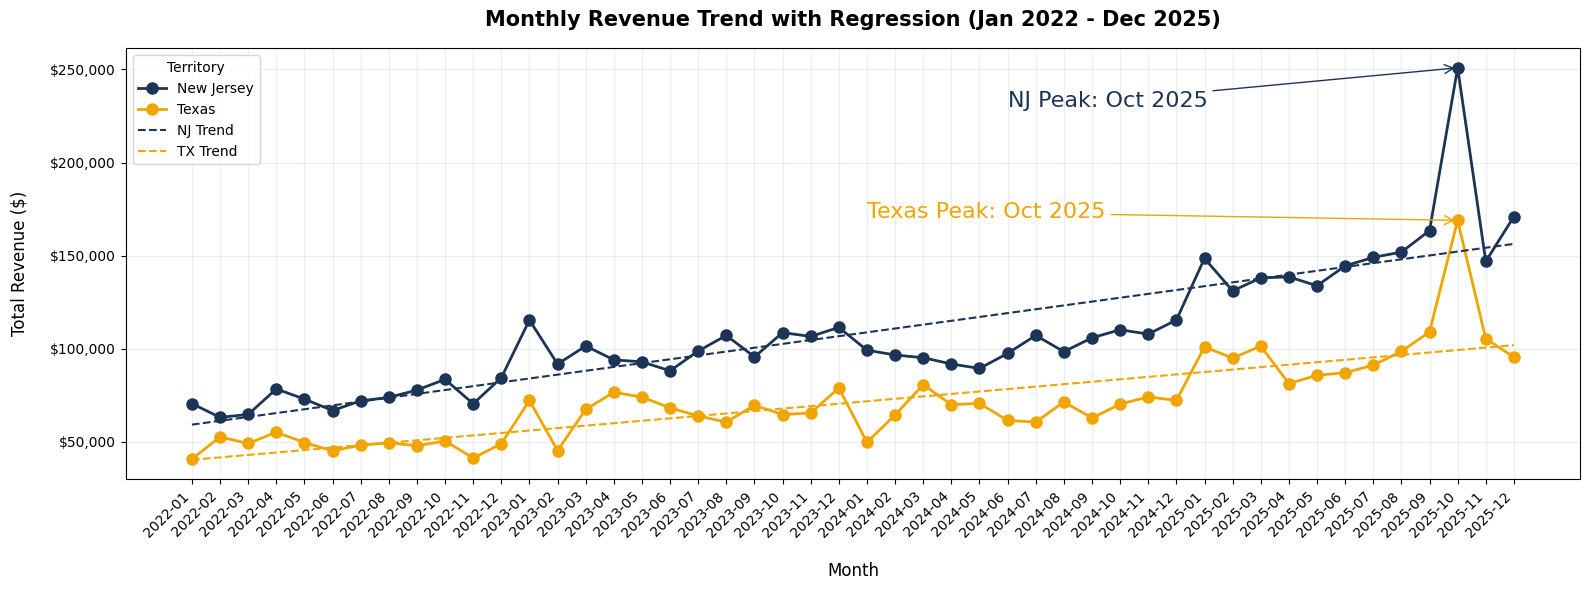

In [16]:
# Create Canvas
# plt.subplots returns a figure and one axes object
# figsize=(16,6) — wide canvas to fit all 48 month labels without crowding
fig, ax = plt.subplots(figsize=(16, 6))

# Regression Setup 
# np.arange creates evenly spaced numbers [0,1,2...47] representing each month
x_numbers = np.arange(len(revenue))

# np.polyfit finds the best-fit straight line through the monthly revenue points
# arguments: x positions, y values (revenue), 1 = linear (straight line)
# returns [slope, intercept] as coefficients
z_nj = np.polyfit(x_numbers, revenue['New Jersey'], 1)
z_tx = np.polyfit(x_numbers, revenue['Texas'], 1)

# np.poly1d converts the coefficients into a callable function
# calling p_nj(x_numbers) returns the predicted revenue value at each month
predict_nj = np.poly1d(z_nj)
predict_tx = np.poly1d(z_tx)

# Actual Revenue Lines for each territory
ax.plot(revenue.index.astype(str), 
        revenue['New Jersey'], 
        label='New Jersey', 
        color='#1C3557', 
        linewidth=2, 
        marker='o', 
        markersize=8)

ax.plot(revenue.index.astype(str), 
        revenue['Texas'], 
        label='Texas', 
        color='#f0a500', 
        linewidth=2, 
        marker='o', 
        markersize=8)

# Regression Trend Lines 
# Dashed lines are used for aesthetic purposed and to show the overall growth direction
# predict_nj(x_numbers) feeds the month numbers into the trend function
# to get predicted revenue at each point along the straight trend line
ax.plot(revenue.index.astype(str), predict_nj(x_numbers),
        color='#1C3557', linestyle='--', linewidth=1.5, label='NJ Trend')
ax.plot(revenue.index.astype(str), predict_tx(x_numbers),
        color='#F0A500', linestyle='--', linewidth=1.5, label='TX Trend')

# Labels and Title
# labelpad is for spacing
ax.set_title('Monthly Revenue Trend with Regression (Jan 2022 - Dec 2025)', 
             fontsize=15, fontweight='bold', pad=16)
ax.set_xlabel('Month', fontsize=12, labelpad=16)
ax.set_ylabel('Total Revenue ($)', fontsize=12, labelpad=16)

# Callout Annotations
# ax.annotate places a text label with an arrow pointing to a specific data point
# xy= is the exact point being highlighted (x-axis month label, y-axis revenue value)
# xytext= is the position where the text label appears on the grid
# arrowprops draws the connecting arrow from text to the highlighted point
ax.annotate('NJ Peak: Oct 2025',        
            xy=('2025-10', 250830.46),  
            xytext=('2024-06', 230000), 
            fontsize=16,
            color='#1C3557',
            arrowprops=dict(arrowstyle='->', color='#1C3557'))

ax.annotate('Texas Peak: Oct 2025',        
            xy=('2025-10', 168955.72),  
            xytext=('2024-01', 170000),  
            fontsize=16,
            color='#F0A500',             
            arrowprops=dict(arrowstyle='->', color='#F0A500')) 

# Formatting 
# FuncFormatter adds $ and comma formatting to y-axis tick labels
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
plt.xticks(rotation=45, ha='right')
plt.legend(title='Territory')

# Customizing the grid
plt.grid(True, linestyle='-', alpha=0.3, color='#B8C8D8')

# Displaying and saving the chart
plt.tight_layout()
plt.savefig('revenue_trend_chart.png', dpi=150, bbox_inches='tight')
plt.show()

**Q2 Findings — Monthly Revenue Trends**

- The New Jersey territory consistently outperformed Texas across the 48-month period, which may be partially driven by New Jersey operating five additional store locations.
- Although both territories demonstrate a general upward revenue trend over time, there is noticeable month-to-month instability, particularly in Texas during the earlier periods.
- A recurring seasonal pattern appears across both territories, with revenue declines occurring in February 2023, January 2024, and December 2025. Notably, each decline followed a period of peak revenue performance.
- The dashed regression trend lines confirm that **both territories are trending upward** overall across the 48-month period. New Jersey's trend line shows a steeper growth trajectory than Texas, suggesting stronger long-term revenue momentum in the Northeast region. Based on this trajectory, **both territories are projected to continue growing into 2026**, with New Jersey maintaining a stronger growth rate.

Interestingly, a significant revenue spike occurred in **October 2025** for both 
territories, with New Jersey reaching approximately `$250K` and Texas 
reaching approximately `$169K`. However, the following declines suggest that this surge 
was not sustained long term. This pattern may indicate the influence of a 
**promotional event**, **seasonal demand**, or another temporary external factor 
that warrants further investigation.

Additionally, the repeated declines occurring during **winter months** may point to 
seasonal consumer behavior. If EmporiUm's primary consumer base includes students, 
**winter breaks** and lower winter semester activity could potentially help explain 
these recurring slowdowns in sales performance. Further analysis of **product 
category performance** and **customer behavior** may help clarify the factors 
behind these patterns.

### Q3 | Store Sales Performance Overview
*How would you rank the sales performance of each store in each sales territory? Which are the top-performing stores?*

In [17]:
# Using merged territory_sales DataFrame to calculate total sales per store across the
# entire data period. Adding new columns to merged DataFrame to track total sales and total 
# transaction counts

territory_performance = territory_sales.groupby(
    ['State', 'Store ID', 'Store Location']
# Using .agg() to calculate multiple aggregations on grouped data and return each as a new column
).agg( 
    Total_Revenue=('Sale Amount', 'sum'),
    Transaction_Count=('Sale Amount', 'size')
).reset_index()

# Confirming the updated territory_sales
territory_performance.head()

,State,Store ID,Store Location,Total_Revenue,Transaction_Count
0,New Jersey,824,Atlantic City,314513.77,2252
1,New Jersey,825,Bayonne,292353.59,2225
2,New Jersey,826,Cape May,285704.59,2252
3,New Jersey,827,Clifton,301703.77,2327
4,New Jersey,828,East Orange,299936.24,2198


In [18]:
# Filtering territory performance by State
# Filtering Sale Amounts in descending order to identify top stores in Texas
texas_performance = territory_performance[territory_performance['State'] == 'Texas'].sort_values('Total_Revenue', ascending=False)

# Ranking store by highest total revenue
texas_performance['Rank'] = range(1, len(texas_performance) + 1)
texas_performance

,State,Store ID,Store Location,Total_Revenue,Transaction_Count,Rank
20,Texas,905,Beaumont,637818.90,4403,1
25,Texas,910,Fort Worth,351772.59,2208,2
24,Texas,909,Desoto,330720.12,2343,3
21,Texas,906,Cedar Park,312628.27,2320,4
19,Texas,904,Baytown,298163.16,2218,5
23,Texas,908,Denton,298111.45,2164,6
16,Texas,901,Arlington,292987.49,2257,7
17,Texas,902,Austin,291145.00,2226,8
18,Texas,903,Bacliff,280714.34,2174,9
26,Texas,911,Georgetown,269344.64,1469,10


In [19]:
# Filtering territory performance by State
# Filtering Sale Amount in descending order to identify top stores in New Jersey
nj_performance = territory_performance[territory_performance['State'] == 'New Jersey'].sort_values('Total_Revenue', ascending=False)
nj_performance

# Ranking store by highest total revenue
nj_performance['Rank'] = range(1, len(nj_performance) + 1)
nj_performance

,State,Store ID,Store Location,Total_Revenue,Transaction_Count,Rank
11,New Jersey,835,Newark,623163.53,4443,1
14,New Jersey,838,Trenton,597565.68,4294,2
6,New Jersey,830,Hoboken,316775.48,2250,3
0,New Jersey,824,Atlantic City,314513.77,2252,4
10,New Jersey,834,New Brunswick,311056.42,2277,5
9,New Jersey,833,Morristown,307320.52,2258,6
15,New Jersey,839,Vineland,306326.30,2209,7
3,New Jersey,827,Clifton,301703.77,2327,8
12,New Jersey,836,Passaic,300358.95,2163,9
4,New Jersey,828,East Orange,299936.24,2198,10


In [20]:
# Getting top 5 stores from each territory 
texas_top = texas_performance.head(5)
nj_top = nj_performance.head(5)

# Merging top stores from both territories for easy visualization
top_stores = pd.concat([texas_top, nj_top]).sort_values(['State','Total_Revenue'], ascending=[True, True])

# Confirming the merge was successful
top_stores

,State,Store ID,Store Location,Total_Revenue,Transaction_Count,Rank
10,New Jersey,834,New Brunswick,311056.42,2277,5
0,New Jersey,824,Atlantic City,314513.77,2252,4
6,New Jersey,830,Hoboken,316775.48,2250,3
14,New Jersey,838,Trenton,597565.68,4294,2
11,New Jersey,835,Newark,623163.53,4443,1
19,Texas,904,Baytown,298163.16,2218,5
21,Texas,906,Cedar Park,312628.27,2320,4
24,Texas,909,Desoto,330720.12,2343,3
25,Texas,910,Fort Worth,351772.59,2208,2
20,Texas,905,Beaumont,637818.90,4403,1


### Visualization: Top Performing Stores by Territory

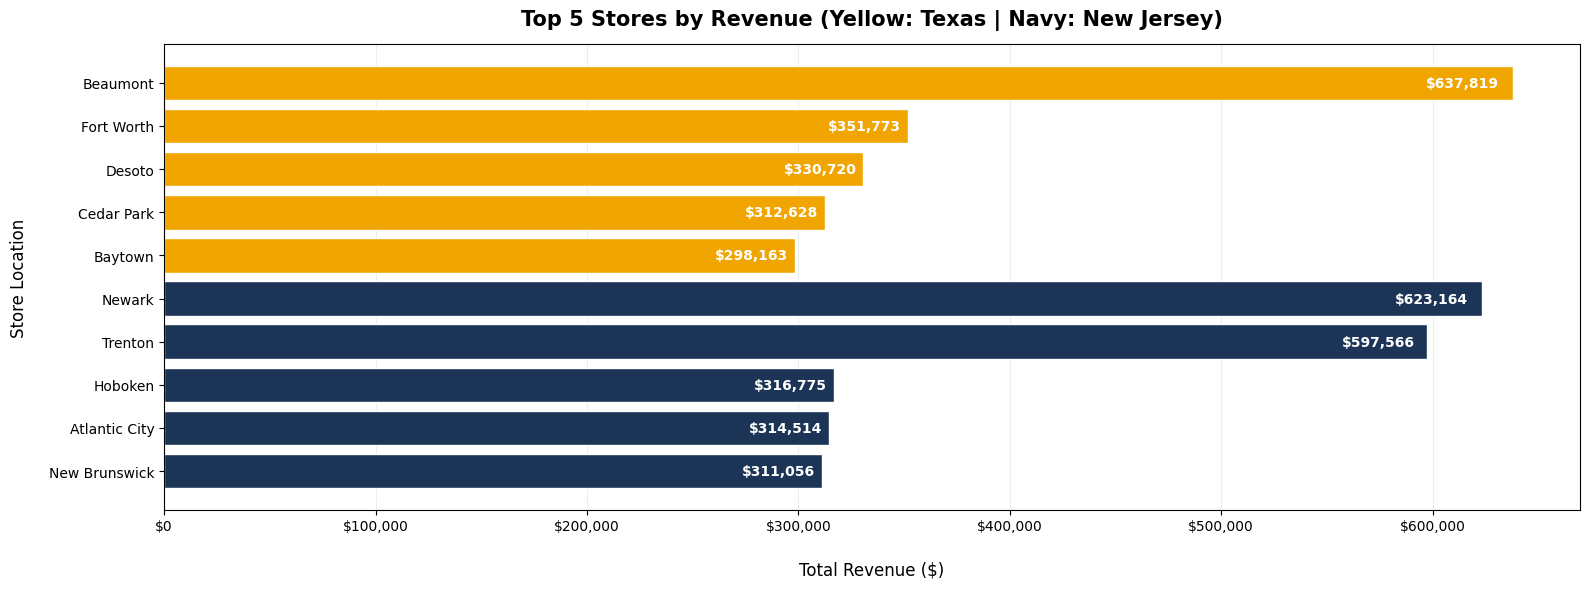

In [21]:
# Create Canvas
# plt.subplots returns a figure and one axes object
# figsize=(16,6) — wide canvas to fit all store name labels cleanly
fig, ax = plt.subplots(figsize=(16, 6))

# ax.set_axisbelow(True) ensures grid lines render behind the bars
ax.set_axisbelow(True)

# Assigning Colors based on Condition
# List comprehension assigns a color to each bar based on territory
# iterates through top_stores State column to match each store to its color
colors = ['#1C3557' if state == 'New Jersey' else '#F0A500'
          for state in top_stores['State']]

# Horizontal Bar Chart
# ax.barh draws bars horizontally
bars = ax.barh(
    top_stores['Store Location'],  # y axis (store names)
    top_stores['Total_Revenue'],   # x axis (revenue values)
    color=colors,
    edgecolor='white'
)

# Dollar Labels Inside Bars
# Loop through each bar object to place a revenue label inside it
# bar.get_width() returns the bar length (revenue value)
# width * 1 positions the text inside the right edge of the bar
# bar.get_y() + bar.get_height()/2 centers the text vertically in the bar
for bar in bars:
    width = bar.get_width()
    ax.text(
        width * .99,
        bar.get_y() + bar.get_height() / 2,
        f'${width:,.0f}',
        va='center',
        ha='right',
        color='white',
        fontweight='bold'
    )

# Labels and Title
# labelpad is for spacing
ax.set_title('Top 5 Stores by Revenue (Yellow: Texas | Navy: New Jersey)',
             fontsize=15, fontweight='bold', pad=14)
ax.set_xlabel('Total Revenue ($)', fontsize=12, labelpad=20)
ax.set_ylabel('Store Location', fontsize=12, labelpad=15)

# Formatting
# FuncFormatter adds $ and comma formatting to x-axis tick labels
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))

# Customizing the grid only on the x-axis
ax.grid(True, linestyle='-', alpha=0.3, color='#B8C8D8', axis='x')

# Displaying and saving the chart
plt.subplots_adjust(right=0.85)
plt.tight_layout()
plt.savefig('store_rankings_chart.png', dpi=150, bbox_inches='tight')
plt.show()

**Q3 Findings — Territory Sales Performance**

- Texas' Beaumont (Store 905) is the top performer across **both** territories 
with `$637,819` in total revenue and 4,403 transactions.
- New Jersey's top performer is Newark (Store 835) at `$623,164` in total revenue and  4,443 transactions.
- Both territories share low-performing outliers. Dallas (TX) at `$54,444` 
with 430 transactions and Paterson (NJ) at `$67,113` with 427 transactions.

Notably, Beaumont generates higher revenue than Newark despite fewer 
transactions, suggesting a higher average transaction value per sale. Across 
both territories, the majority of stores fall within a similar revenue range 
of approximately `$285K`–`$355K` with comparable transaction counts between 
2,100–2,400. This pattern confirms that **New Jersey's overall revenue 
dominance is driven by store count**; 16 stores versus Texas' 11 means more 
opportunities to accumulate transactions and revenue. The Dallas and Paterson 
outliers appear explained by significantly lower transaction volume rather than 
poor store quality, and warrant further investigation into local consumer 
behavior. These stores may benefit from targeted local marketing campaigns or a review of their product mix to gauge consumer demands.

### Q4 | Top Customers by Territory
*Comparing the customer ID from the customer list data with the rewards ID from the sales data, who were the top customers in each sales territory?*

In [22]:
# Merging territory_sales with customer_list to identify customer names
# Using left merge to keep all transactions including non-rewards customers
# left_on/right_on used because join columns have different names
territory_customers = pd.merge(territory_sales, customer_list, left_on='RewardsID', right_on='cust_id', how='left')
territory_customers.head()

,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount,YearMonth,Store Location,State,Territory Manager,Region,Region Director,cust_id,date,time,name,email,phone,sms-opt-out
0,2022-01-01,824,NaN,105337-IT,1301.88,2022-01,Atlantic City,New Jersey,Miami Vue,Northeast,Michael Jarvis,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2022-01-01,826,513.0,105435-A,18.00,2022-01,Cape May,New Jersey,Miami Vue,Northeast,Michael Jarvis,513.0,2023-04-23,12:50:30,Ferb Fletcher,ferb@danvillekids.com,555-555-3202,N
2,2022-01-01,826,NaN,105436-S,4.32,2022-01,Cape May,New Jersey,Miami Vue,Northeast,Michael Jarvis,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2022-01-01,827,122.0,105274-IT,296.60,2022-01,Clifton,New Jersey,Miami Vue,Northeast,Michael Jarvis,122.0,2023-09-28,14:30:30,Henrietta Pussycat,meow@neighborhood.org,412-555-9507,N
4,2022-01-01,828,NaN,105437-T,187.25,2022-01,East Orange,New Jersey,Miami Vue,Northeast,Michael Jarvis,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [23]:
# Filtering only rewards members (dropping non-rewards null transactions)
rewards_only = territory_customers[territory_customers['RewardsID'].notna()]
rewards_only.head()

,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount,YearMonth,Store Location,State,Territory Manager,Region,Region Director,cust_id,date,time,name,email,phone,sms-opt-out
1,2022-01-01,826,513.0,105435-A,18.00,2022-01,Cape May,New Jersey,Miami Vue,Northeast,Michael Jarvis,513.0,2023-04-23,12:50:30,Ferb Fletcher,ferb@danvillekids.com,555-555-3202,N
3,2022-01-01,827,122.0,105274-IT,296.60,2022-01,Clifton,New Jersey,Miami Vue,Northeast,Michael Jarvis,122.0,2023-09-28,14:30:30,Henrietta Pussycat,meow@neighborhood.org,412-555-9507,N
22,2022-01-01,908,328.0,105337-IT,1301.88,2022-01,Denton,Texas,"Jeff ""Howdy"" Richards",South,Andy Gisselquist,328.0,2023-08-23,14:55:15,Monica Reyes,reyes@fbi.gov,202-555-1307,N
36,2022-01-02,835,515.0,105519-A,44.50,2022-01,Newark,New Jersey,Miami Vue,Northeast,Michael Jarvis,515.0,2023-09-19,21:40:00,Isabella G.,isabella@danvillekids.com,555-555-3204,Y
39,2022-01-02,836,214.0,105525-T,204.58,2022-01,Passaic,New Jersey,Miami Vue,Northeast,Michael Jarvis,214.0,2023-12-17,21:35:15,Nicky B.,nicky@banksresidence.la,310-555-1409,N


In [24]:
# Grouping by State and customer to calculate total spend per customer
# Using .agg() to get both total spend and transaction count
top_customers = rewards_only.groupby(
    ['State', 'cust_id', 'name']
).agg(
    Total_Spend=('Sale Amount', 'sum'),
    Transaction_Count=('Sale Amount', 'size')
).reset_index()

top_customers

,State,cust_id,name,Total_Spend,Transaction_Count
0,New Jersey,1.0,Rachel,318.88,6
1,New Jersey,2.0,R. Geller,295.76,4
2,New Jersey,3.0,Monica Geller,732.32,7
3,New Jersey,4.0,Chandler Bing,879.99,13
4,New Jersey,5.0,Joey,500.36,4
...,...,...,...,...,...
1034,Texas,517.0,Perry the Platypus,12.02,2
1035,Texas,518.0,Baljeet,1440.17,6
1036,Texas,519.0,Buford,368.19,7
1037,Texas,520.0,Vanessa D.,279.17,6


In [25]:
# Getting top 5 customers per territory sorted by total spend
top5_tx_customers = top_customers[top_customers['State'] == 'Texas'].sort_values('Total_Spend', ascending=False).head(5)
top5_nj_customers = top_customers[top_customers['State'] == 'New Jersey'].sort_values('Total_Spend', ascending=False).head(5)

print("Top 5 Texas Customers:")
display(top5_tx_customers)
print("\nTop 5 New Jersey Customers:")
display(top5_nj_customers)

Top 5 Texas Customers:


,State,cust_id,name,Total_Spend,Transaction_Count
862,Texas,344.0,Nate Jacobs,5240.86,10
991,Texas,474.0,Christopher Moltisanti,3479.46,7
621,Texas,102.0,Jodie L.,3464.91,13
687,Texas,168.0,Darius,3400.35,9
789,Texas,271.0,Maeby F.,3127.53,11



Top 5 New Jersey Customers:


,State,cust_id,name,Total_Spend,Transaction_Count
340,New Jersey,341.0,Ben Linus,4810.66,8
457,New Jersey,458.0,Kim Wexler,4215.58,7
239,New Jersey,240.0,Nicky Nichols,4164.21,12
32,New Jersey,33.0,Bart,3862.61,10
160,New Jersey,161.0,Lieutenant Duffy,3859.16,8


In [26]:
# Average spend per transaction for top customers for each territory at this time
print("Texas Top Customer: Nate Jacobs")
print(f"Current average per transaction: ${5241/10:,.2f}")

print("\nNew Jersey Top Customer: Ben Linus")
print(f"Current average per transaction: ${4811/8:,.2f}")

Texas Top Customer: Nate Jacobs
Current average per transaction: $524.10

New Jersey Top Customer: Ben Linus
Current average per transaction: $601.38


### Visualization: Top Customers by Spend

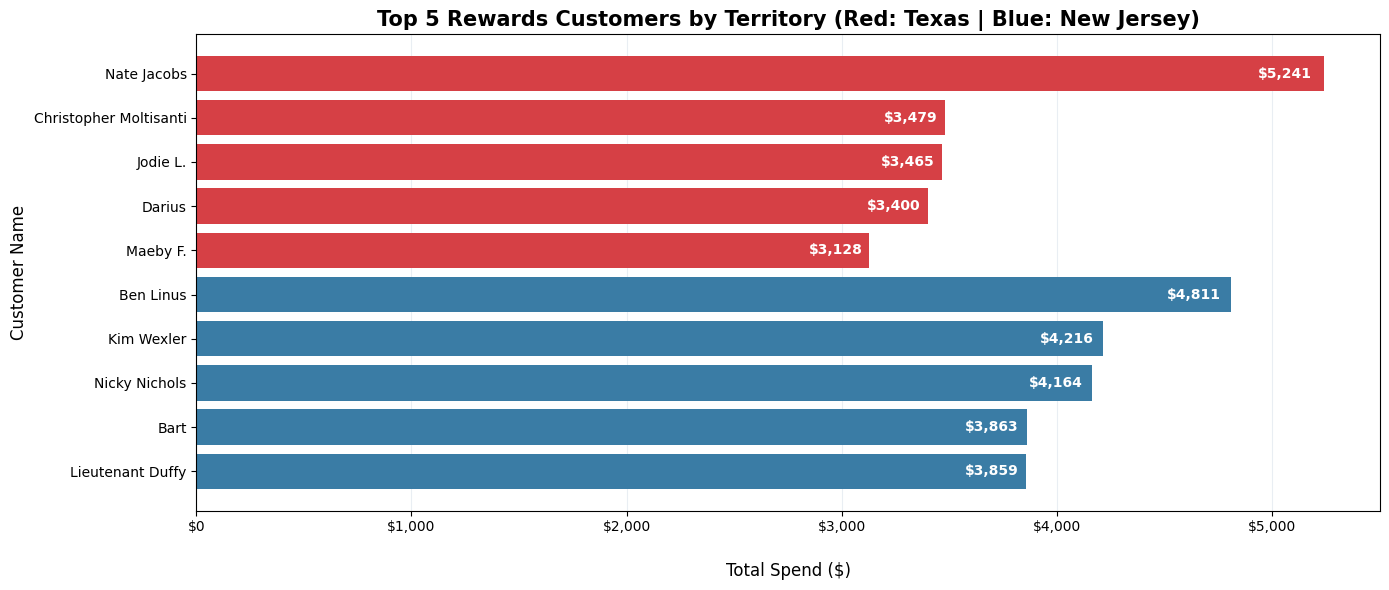

In [27]:
# Combining Results for Both Territories for Easy Visualization
# pd.concat stacks the two territory DataFrames vertically into one
# sort_values organizes by State then Total_Spend for clean grouped display
top_customers_combined = pd.concat([top5_tx_customers, top5_nj_customers]).sort_values(['State', 'Total_Spend'])

#  Create Canvas
fig, ax = plt.subplots(figsize=(14, 6))

# ax.set_axisbelow(True) ensures grid lines render behind bars
ax.set_axisbelow(True)

# Assigning Colors based on Condition
# List comprehension assigns color per bar based on territory
# Steel bluefor New Jersey, Red for Texas
colors = ['#3A7CA5' if state == 'New Jersey' else '#D64045'
          for state in top_customers_combined['State']]

# Horizontal Bar Chart 
# y axis = customer names, x axis = total spend
# horizontal layout chosen because customer names are long strings
bars = ax.barh(
    top_customers_combined['name'],
    top_customers_combined['Total_Spend'],
    color=colors
)

# Dollar Labels Inside Bars
# Loop places a formatted spend label inside the right edge of each bar
# width * 0.98 keeps label just inside the bar edge
# get_y() + get_height()/2 centers label vertically within the bar
for bar in bars:
    width = bar.get_width()
    ax.text(
        width * 0.99,
        bar.get_y() + bar.get_height() / 2,
        f'${width:,.0f}',
        va='center',
        ha='right',
        color='white',
        fontweight='bold'
    )

# Labels and Title 
# labelpad is for spacing
ax.set_title('Top 5 Rewards Customers by Territory (Red: Texas | Blue: New Jersey)',
             fontsize=15, fontweight='bold')
ax.set_xlabel('Total Spend ($)', fontsize=12, labelpad=20)
ax.set_ylabel('Customer Name', fontsize=12)

# Formatting
# FuncFormatter adds $ and comma formatting to x-axis tick labels
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))

# Customizing the grid only on the x-axis
ax.grid(True, linestyle='-', alpha=0.3, color='#B8C8D8', axis='x')

# Displaying and saving the chart
plt.tight_layout()
plt.savefig('top_customers_chart.png', dpi=150, bbox_inches='tight')
plt.show()

**Q4 Findings — Customer Spend Overview**

- Texas' top rewards customer is **Nate Jacobs** at a total spend of `$5,241` with only 10 transactions, averaging approximately `$524` per transaction. Similarly, New Jersey's top spender is **Ben Linus** at a grand total of `$4,811` with only 8 transactions, averaging approximately `$601` per transaction. Interestingly, despite NJ's overall revenue dominance, Texas claims the **top individual rewards spender**, suggesting a group of high-value customers whose potential is not yet fully reflected at the territory level.
- Both customers demonstrate high spend per visit. However, whether driven by purchasing 
multiple products or higher-priced items cannot be determined from this data alone, 
but either pattern signals strong purchasing behavior worth retaining.
- A key limitation is that this **analysis covers rewards members only. Non-rewards 
customers cannot be individually identified**, meaning high-value unregistered spenders 
may exist without visibility, a significant gap in customer data.

Despite relatively low transaction counts, both top customers generate significantly 
higher revenue per visit than average, suggesting targeted VIP engagement could 
further increase their spend and visit frequency. To address the rewards gap, marketing should consider a points-based rewards expansion tied to email at checkout, since every transaction already captures an email address. This would help track purchasing behavior for ALL customers, not just rewards members. Tying spend toward discounts or exclusive perks would incentivize repeat visits and reward loyal customers. This initiative would drive higher enrollment, increase transaction frequency and overall revenue, and improve customer visibility across both territories.

### Q5 | Product Category Performance by Territory
*What is the number of transactions per month by product category in each assigned territory? What is total sales revenue per month by category?*

In [28]:
# Keeping only unique Category rows to avoid duplicate rows on merge
categories_unique = product_categories[['CategoryID', 'Category']].drop_duplicates()

# Merging territory_sales with products and unique category names
territory_categories = territory_sales.merge(
    products, on='Prod Num'
).merge(
    categories_unique, on='CategoryID'
)

# Confirming the merge was successful
territory_categories.head()

,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount,YearMonth,Store Location,State,Territory Manager,Region,Region Director,Product,CategoryID,SubcategoryID,Category
0,2022-01-01,824,NaN,105337-IT,1301.88,2022-01,Atlantic City,New Jersey,Miami Vue,Northeast,Michael Jarvis,HP Pavilion 14,120,120-lap,Technology & Accessories
1,2022-01-01,826,513.0,105435-A,18.00,2022-01,Cape May,New Jersey,Miami Vue,Northeast,Michael Jarvis,Plaster of Paris (5 lbs),115,115-scu,Art Supplies
2,2022-01-01,826,NaN,105436-S,4.32,2022-01,Cape May,New Jersey,Miami Vue,Northeast,Michael Jarvis,Rhodia DotPad No,110,110-not,Stationery and Supplies
3,2022-01-01,827,122.0,105274-IT,296.60,2022-01,Clifton,New Jersey,Miami Vue,Northeast,Michael Jarvis,Visual Studio 2022,120,120-sof,Technology & Accessories
4,2022-01-01,828,NaN,105437-T,187.25,2022-01,East Orange,New Jersey,Miami Vue,Northeast,Michael Jarvis,Data Structures and Algorithms,100,100-eng,Textbooks


In [29]:
# Using .agg() to calculate total revenue and transaction count grouped by State and Category
# and add the results as new columns
category_performance = territory_categories.groupby(
    ['State', 'Category']
).agg(
    Total_Revenue=('Sale Amount', 'sum'),
    Transaction_Count=('Sale Amount', 'size')
).reset_index()

# Sorting results in descending order to display highest transaction counts first
category_performance.sort_values('Transaction_Count', ascending=False)

,State,Category,Total_Revenue,Transaction_Count
3,New Jersey,Stationery and Supplies,83170.46,8265
4,New Jersey,Technology & Accessories,3630738.42,7883
0,New Jersey,Apparel and Merchandise,237281.41,7353
1,New Jersey,Art Supplies,197096.50,6129
5,New Jersey,Textbooks,936799.67,5419
9,Texas,Stationery and Supplies,54322.23,5396
10,Texas,Technology & Accessories,2445117.66,5219
6,Texas,Apparel and Merchandise,142403.22,4406
7,Texas,Art Supplies,120953.81,3787
11,Texas,Textbooks,596616.41,3423


In [30]:
# Creating and displaying pivot table for grouped bar chart visualization
category_pivot = pd.pivot_table(
    category_performance,
    index='Category',
    columns='State',
    values='Total_Revenue',
    aggfunc='sum'
).fillna(0)

category_pivot

State,New Jersey,Texas
Category,,
Apparel and Merchandise,237281.41,142403.22
Art Supplies,197096.50,120953.81
Books (General),90319.41,58436.68
Stationery and Supplies,83170.46,54322.23
Technology & Accessories,3630738.42,2445117.66
Textbooks,936799.67,596616.41


### Visualization: Revenue by Product Category and Territory

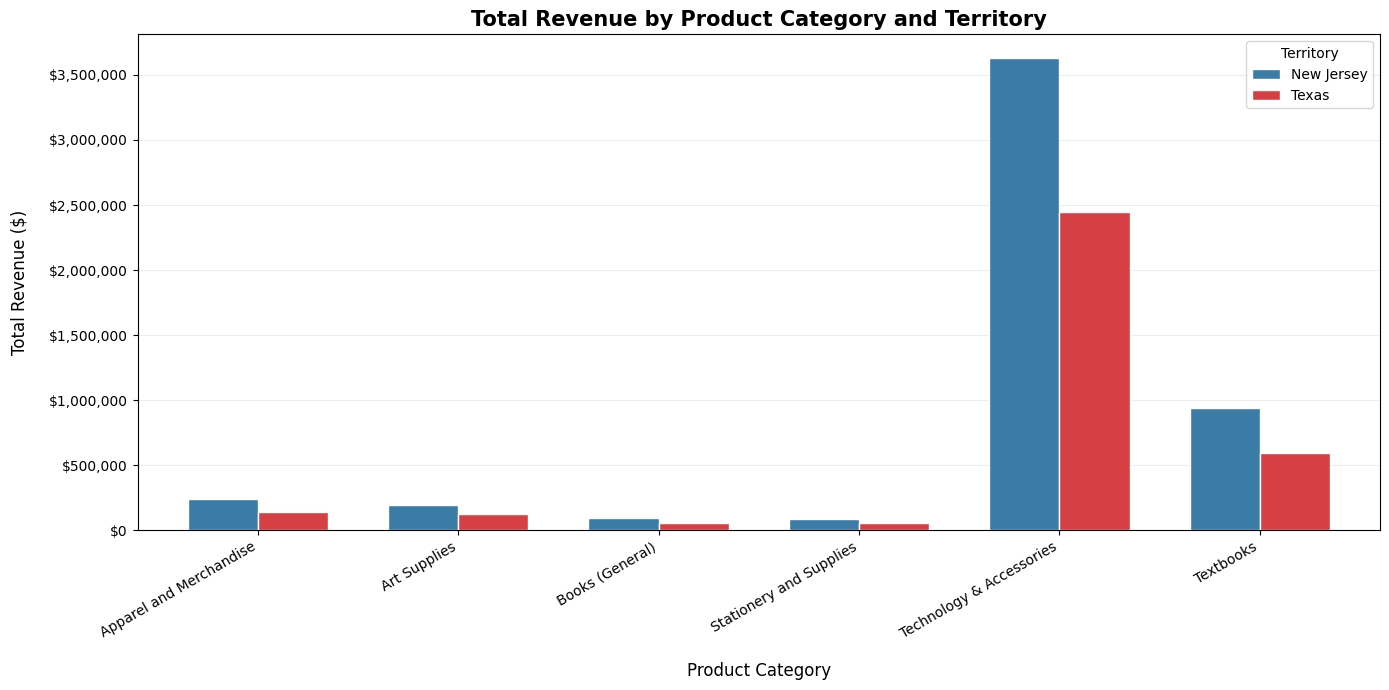

In [31]:
# Create Canvas
# extra height prevents x-axis labels from overlapping bars
fig, ax = plt.subplots(figsize=(14, 7))

# ax.set_axisbelow(True) ensures grid lines render behind bars
ax.set_axisbelow(True)

# Grouped Bar Chart from Pivot Table 
# category_pivot has Category as index and State as columns
# kind='bar' creates one bar per territory per category
# each row in the pivot becomes a group, each column becomes one bar in that group
category_pivot.plot(
    kind='bar',
    ax=ax,
    color=['#3A7CA5', '#D64045'],  # Blue for NJ, Red for TX
    edgecolor='white',
    width=0.7  # slight gap between bar groups for readability
)

# Labels and Title
ax.set_title('Total Revenue by Product Category and Territory',
             fontsize=15, fontweight='bold')
ax.set_xlabel('Product Category', fontsize=12, labelpad=15)
ax.set_ylabel('Total Revenue ($)', fontsize=12, labelpad=15)

# Formatting 
# FuncFormatter adds $ and comma formatting to y-axis tick labels
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))

# rotation=30 keeps category labels readable without taking too much vertical space
# ha='right' right-aligns rotated labels so they point toward their bars
plt.xticks(rotation=30, ha='right')

# legend box clarifies which color represents which territory
plt.legend(title='Territory')

# Customizing grid lines on y-axis only
ax.grid(True, linestyle='-', alpha=0.3, color='#B8C8D8', axis='y')

# Displaying and saving chart
plt.tight_layout()
plt.savefig('category_revenue_chart.png', dpi=150, bbox_inches='tight')
plt.show()

**Q5 Findings — Product Category Performance**

- **Technology & Accessories** is the dominant revenue category in both territories, 
generating approximately `$3.6M` in New Jersey and `$2.4M` in Texas, far exceeding 
every other category. New Jersey leads Texas in every single category, as they have more opportunities for sales based on store count alone.
- **Stationery and Supplies** presents an interesting opportunity. Although it generates disproportionately low revenue overall, `$83,170` in New Jersey and `$54,322` in Texas, it ranks as the highest transaction count category in both territories. This pattern suggests 
customers are purchasing frequently but spending minimally per transaction.
- **Books (General)** is the lowest revenue performer in both territories, with 
relatively low transaction counts as well, indicating low overall demand. This may suggest an opportunity to reduce Books inventory without completely eliminating it to meet demands of expanding higher-margin categories like Technology & Accessories.

**Technology & Accessories** and **Textbooks** drive the majority of revenue, while 
**Stationery and Supplies**, **Apparel**, and **Art Supplies** show high transaction 
frequency but low revenue contribution. Further pricing analysis on Stationery and 
Supplies is worth conducting because small price increases or bundle strategies could meaningfully impact revenue without disrupting existing demand.

---

## 3. Marketing Focus Recommendations for Next Quarter


### 3.A Executive Summary

Across the 48-month analysis period (January 2022 – December 2025), the Texas and 
New Jersey territories generated a combined revenue driven primarily by **Technology 
& Accessories** and **Textbooks**. 

**Key Insights**:

| Metric | New Jersey | Texas |
|---|---|---|
| Total Stores | 16 | 11 |
| Top Store | Newark (623,164) | Beaumont (637,819) |
| Top Rewards Customer | Ben Linus (4,811) | Nate Jacobs (5,241) |
| #1 Revenue Category | Technology & Accessories | Technology & Accessories |
| Peak Month | October 2025 (250,830) | October 2025 (168,956) |
| Revenue Trend | Upward | Upward |

Both territories are *trending upward* with clear opportunities for growth in 
underperforming categories and untapped customer groups.

---

### 3.B Strategies

Based on the full analysis of store performance, customer behavior, and product 
category trends across Texas and New Jersey, the following recommendations are 
made for `Q1 2026`:


---
<div style="background-color: #f0f7f0; padding: 20px; border-radius: 8px; border-left: 4px solid #4a7c59;">

**Primary Focus**: *Technology & Accessories*

Technology & Accessories is the clear revenue driver across both territories, 
generating over `$6M` combined. With both territories trending upward and this 
category dominating all others, marketing efforts should prioritize promoting 
technology products, especially in Texas where the gap with New Jersey is largest 
and growth potential remains significant. Despite trailing New Jersey in total 
technology revenue, Texas demonstrates strong customer loyalty. Leveraging this 
by offering care packages or accessories bundles with technology purchases could 
incentivize both existing loyal customers and new ones to increase their spend in 
this category.

---

**Secondary Focus**: *Stationery and Bundle Strategy*

Stationery and Supplies has the highest transaction volume across both territories 
but generates disproportionately low revenue per transaction, suggesting customers 
purchase frequently but spend minimally per visit. To capitalize on this existing 
demand, introducing bundle promotions that pair Stationery & Supplies with 
higher-priced categories could increase average transaction size without disrupting 
current purchase behavior. Possible bundles could include Books (General) or Art 
Supplies as a back-to-school or premium studying package, simultaneously lifting 
revenue across three low-performing categories while targeting what the seasonal 
data suggests may be a predominantly student consumer base.

---

**Customer Retention**: *VIP Rewards Expansion*

High-value rewards customers like Nate Jacobs (Texas) and Ben Linus (NJ) average 
over `$500` per transaction despite low visit frequency, signaling strong 
purchasing intent when they do engage. A points-based VIP rewards expansion 
targeting high spenders could increase transaction frequency and drive enrollment 
among non-rewards customers who currently cannot be tracked. Since every 
transaction is already tied to an email address, implementing a lightweight 
email-based tracking system would provide full visibility into customer behavior 
across both territories, not just rewards members.

---

**Store Performance Disparity**: *Address Outliers*

Dallas (TX) and Paterson (NJ) both show significantly lower transaction counts 
than comparable stores in their respective territories. This is particularly 
surprising for Dallas, which serves a metropolitan population of approximately 
**1.3 million according to the U.S. Census Bureau**, suggesting location alone is 
not the issue. Further investigation into local brand awareness and consumer 
behavior at both locations is worth conducting to better understand what is 
driving the large gap.

Both stores could benefit from a store quality audit examining foot traffic, 
product placement, and staff engagement across top and low-performing stores. Jeff Richards and Miami Vue should look at what is working at top-performing stores like Beaumont (Texas) and Newark (NJ) and consider applying those same tactics at Dallas and Paterson. Replicating strategies from within the territory is a practical first step before investing in larger external campaigns.

</div>